# 1. World records as measures of senescence

## 1.1 Introduction

This exercise consists of running simulations with three probabilities functions (normal, exponential and lognormal) to show that sample size is a major issue with the study of senescence and drops in performance: https://callingbullshit.org/case_studies/case_study_track_records.html


## 1.2 Visualize the decrease in world records by age

The first step is to recreate the original line chart of Bergstrom & Dugatkin (2016) that shows world records decreasing by age. Since some records correspond to the lowest value (e.g., the 100m dash) while others correspond to the highest value (i.e., the longjump), we first define two functions to scale both types of records so we could compare different records if we wanted to.

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
import math
import random

# Function that scales the data in case of records where lower is better
def scale_records(data):
    record = min(data)
    data_scaled = [record / x for x in data]
    return data_scaled

# Function that scales the data in case of records where higher is better
def scale_data(data):
    best = max(data)
    data_scaled = [x / best for x in data]
    return data_scaled

# Set random seed
np.random.seed(42)

We include the records on the 100m dash for different age groups below:

In [2]:
# 100m dash world records (2016)
records_100 = [9.58, 9.96, 10.29, 10.72, 10.88, 11.39, 11.70, 12.37, 12.77, 13.49, 14.35, 15.97, 17.53, 20.41, 29.83]
age = [20, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100]

Now create a plot of the scaled records vs. age.

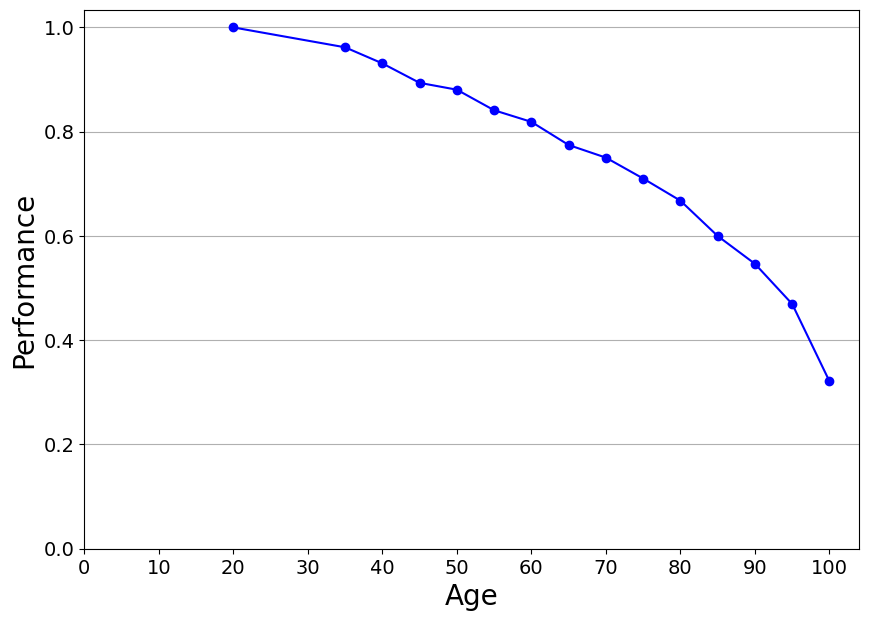

In [ ]:
# Scale the records in scores of perfomance in relation to the world record.
records_100_scaled = # Your code here
    
# Plot the evolution of performance according the age.
plt.figure(figsize=(10,7))

plt.plot() # Your code here

plt.xlabel('Age', fontsize=20)
plt.ylabel('Performance', fontsize=20)
plt.xticks(np.arange(0, 110, 10), fontsize=14)
plt.yticks(np.arange(0, 1.2, 0.2), fontsize=14)
plt.grid(axis = 'y')
plt.show()

## 1.2.1 The Long Jump - Alternate dataset

The next section simulates the data according to different distributions using **inverse transform sampling**.

As indicated in the article by Bergstrom, you will need to *"**take the highest [100m dash time]** (again scaled relative to the highest score overall) and plot it"*.

Intuitively, this does not make much sense in the context of a 100m dash, where smaller values (faster times) are better.  

But this is necesarry when generating values with **inverse transform sampling** for this purpose.

This change here is simply intended to make the process a little easier to follow. Ultimately, feel free to use whichever data/event you want!  

Records on the long jump for different age groups below [[source](https://en.wikipedia.org/wiki/List_of_world_records_in_masters_athletics#Long_jump)] :

In [4]:
jump_100 = [8.5, 7.77, 7.27, 6.84, 6.5, 6.18, 5.54, 5.22, 4.83, 4.45, 3.83, 3.26, 2.31, 1.78]
age = [35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100]

Create a plot of the scaled records vs. age (again)

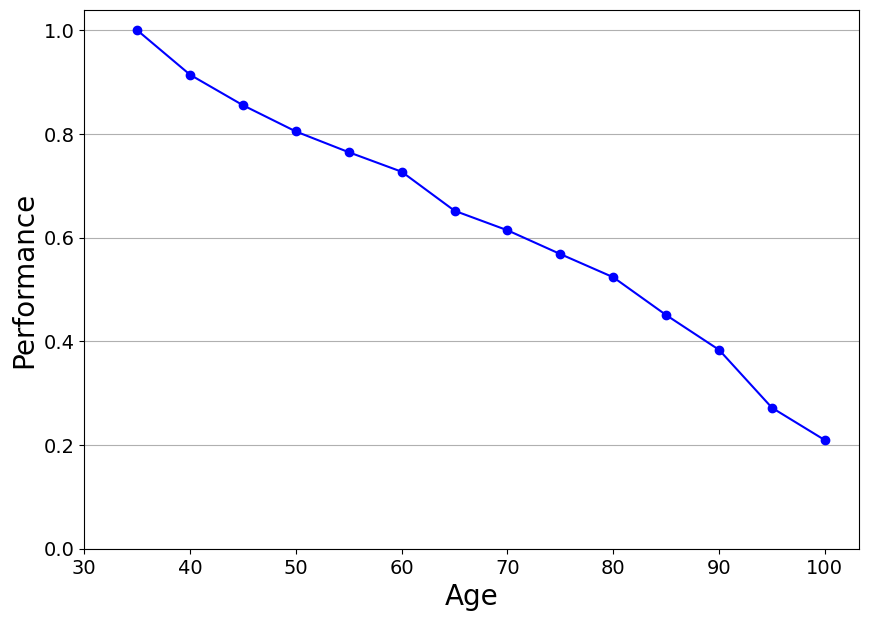

In [ ]:
jump_100_scaled = # Your code here

# Plot the evolution of performance according the age.
plt.figure(figsize=(10,7))

plt.plot()# Your code here

plt.xlabel('Age', fontsize=20)
plt.ylabel('Performance', fontsize=20)
plt.xticks(np.arange(30, 110, 10), fontsize=14)
plt.yticks(np.arange(0, 1.2, 0.2), fontsize=14)
plt.grid(axis = 'y')
plt.show()

## 2.1 Simulate the effects of different sample sizes

Now we recreate the second plot from the lecture where we compare the impact of different sample sizes on the records.  

For this, you need to generate samples of 100m Dash **or** Long Jump distances drawn from three different distributions: 
1. normal, 
2. exponential, and 
3. log-normal.  

You could try out the following sample sizes:  
1.000.000, 100.000, 10.000, 1.000, 100, 10  

We recommend you do this using [inverse transform sampling](https://en.wikipedia.org/wiki/Inverse_transform_sampling).
* Start with taking *n* samples from a uniform distribution
* These values essentially represent quantiles of our distribution
* Use the inverse Cumulative Distrinution Function (CDF), know as the Percentage Point Function (PPF), to determine what value corresponds to the generated percentile(s)
  * Hint: **stats.norm.ppf(uniform_samples, loc=mu, scale=sigma)**
* It is recommended to take the max() of these values to avoid negative results, even though this is counterintuitive to finding the **fastest** running time
  * e.g. If we consider running times with  mu = 10, and sigma = 5, considering that $99.7$% of the values fall within 3 standard deviations of the mean, you could *potentially* get negative running times, which is impossible.

**Example:**  
*mu* = 10  
*sigma* = 5  

*uniform_samples(3)* = [0.001, 0.5, 0.9]  

*stats.norm.ppf(Generated quantiles, mu, sigma)* = [-5.45, 10.0, 16.41]  

*max(Generated running times)* = 16.41

In [ ]:
# Sample sizes
populations = [1_000_000, 100_000, 10_000, 1_000, 100, 10]

# Calculate the mean and standard deviation from all our data. In the case of our null model, 
# there is no senescence and performance is record performance is stable over the years, so we
# take the average of our current set of scores, regardless of age.
mu = # Your code here
sigma = # Your code here

# Function for performing inverse transform sampling
# Start with a normal distribution, and then go from there.
# You can use/reuse the template below for the exponential and log-normal distributions, 
# combine everything into 1 function, 
# or do something else entirely!

def inverse_transform_sampling(populations, mu, sigma):
    samples = []

    for population_size in populations:
        # Your code here
        # It is recommended that you repeat the sampling multiple times, and take the resulting mean

    return samples

records_normal = inverse_transform_sampling(populations, mu, sigma)

In [ ]:
# Repeat for the other distribution types.
records_exponential = inverse_transform_sampling(populations, mu, sigma)

records_lognormal = inverse_transform_sampling(populations, mu, sigma)

## 2.2 Plot simulated values

Once you've performed the inverse transform sampling for all three distribution types, remember to **correctly** scale the values and plot them.  

If you worked with the 100m Dash times, smaller is better.  

If you worked with the Long Jump times, larger is better.

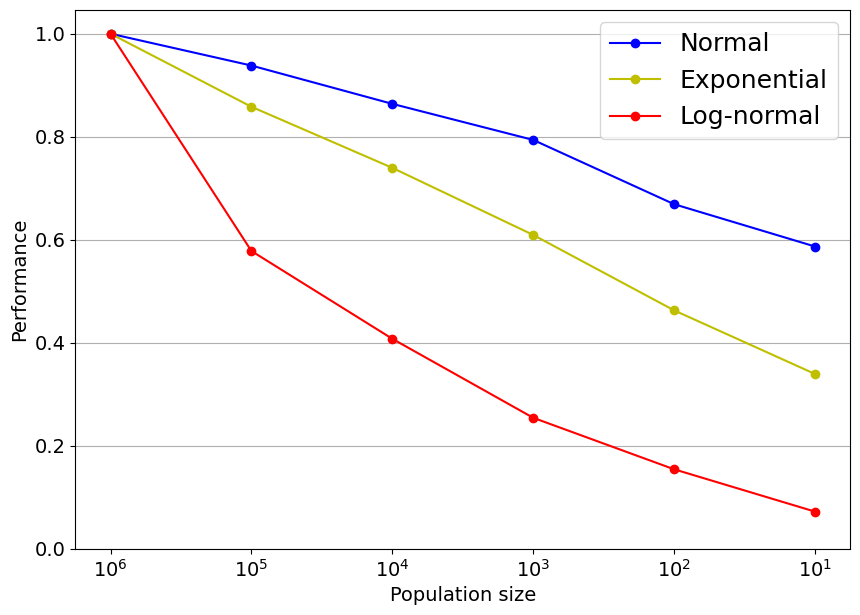

In [ ]:
# Scale the data.
y_normal = 
y_exponential = 
y_lognormal = 


# Generate the plot.
x = [i+1 for i in range(len(populations))] # this should adjust the plot according to how many population sizes you want to try out
x_axis = [f"$10^{i}$" for i in x[::-1]]

plt.figure(figsize=(10,7))

plt.plot() # Normal
plt.plot() # Exponential
plt.plot() # Log-normal

plt.legend(fontsize=18)
plt.xlabel('Population size', fontsize = 14)
plt.ylabel('Performance', fontsize = 14)
plt.xticks(x,  x_axis, fontsize = 14)
plt.yticks(np.arange(0, 1.2, 0.2), fontsize = 14)
plt.grid(axis = 'y')

As we also showed in class, descreasing sample sizes for different distributions—and especially the normal distribution—can also explain the pattern, so the original plot is not convincing evidence of senescence in terms of world records.  

If you want, you can now repeat this with another types of records.  
You will need to find these records for the different age groups yourself.